## Object: Develop and implement two classification models using Sex as the target variable

## Models: KneighborsClassifier, Decision Tree, Logistic Regression, Random Forest

## Unit of measure from the features
- Whole_weight, Shucked_weight, Viscera_weight, Shell_weight = **Grams (g)**
- Length,Diameter, Height = **Millimetres (mm)**
- Rings = **Count = Int**
- Sex = **N/A**

## Import Libraries

In [1]:
# Import libraries
import pandas as pd                                                # Manipulate data
import numpy as np                                                 # Numeric operations
import matplotlib.pyplot as plt                                    # Visualization library
import seaborn as sns                                              # Visualization library more friendly

import warnings
warnings.filterwarnings("ignore")                                   # Ignore warnings

from sklearn.preprocessing import StandardScaler                    # StandardScaler
from sklearn.model_selection import train_test_split                # Split the data into train and test
from sklearn.metrics import accuracy_score                          # Accuracy metric
from sklearn.metrics import confusion_matrix                        # confusion_matrix (true x predict)
from sklearn.metrics import classification_report                   # Precision/recall/f1 report

## Load the data

In [2]:
df = pd.read_csv("abalone.csv")        # Load the data

df                                     # Display the 5 first and last 5 rows

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4175,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4176,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4177,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4178,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


## Get extra information about the data

In [3]:
# overview of the type of each column, number of rows and columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4180 non-null   str    
 1   Length          4180 non-null   float64
 2   Diameter        4180 non-null   float64
 3   Height          4172 non-null   float64
 4   Whole_weight    4180 non-null   float64
 5   Shucked_weight  4175 non-null   float64
 6   Viscera_weight  4175 non-null   float64
 7   Shell_weight    4180 non-null   float64
 8   Rings           4180 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 298.1 KB


In [4]:
# Summary statistics of the numeric columns
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4180.000000,4180.000000,4172.000000,4180.000000,4175.000000,4175.000000,4180.000000,4180.000000
mean,0.523927,0.407827,0.139494,0.828459,0.359339,0.180621,0.238759,9.933014
std,0.120096,0.099247,0.041822,0.490379,0.222031,0.109620,0.139197,3.224667
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441375,0.186000,0.093250,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.233750,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.328625,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Based on this statistical summary, we see that:

There are very different ranges between features:

| Feature | Min | Max |
|---|---|---|
| **Length** | 0.075 | 0.815 |
| **Diameter** | 0.055 | 0.65 |
| **Shucked_weight** | 0.001 | 1.488 |
| **Whole_weight** | 0.002 | 2.825 |
| **Viscera_weight** | 0.0005 | 0.76 |
| **Shell_weight** | 0.0015 | 1.005 |
| **Height** | 0 | 1.130 |

> **Height** — 75% of the data is below **0.165**, despite the maximum being **1.130**

> **Rings** — although the mean is **9.93** and the median is **9**, the maximum value is **29**, much higher than the 75th percentile (**11**)

---

> The fact that the features have different units of measurement is another good reason for using the **Standard Scaler**.

## Check if there are null values on the data

In [5]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            8
Whole_weight      0
Shucked_weight    5
Viscera_weight    5
Shell_weight      0
Rings             0
dtype: int64

### Due to the fact that we see some outliers in the graphs above, referring to the 3 features with null values, the median is more robust than the mean in handling these values.

Text(0.5, 1.0, 'Viscera_weight')

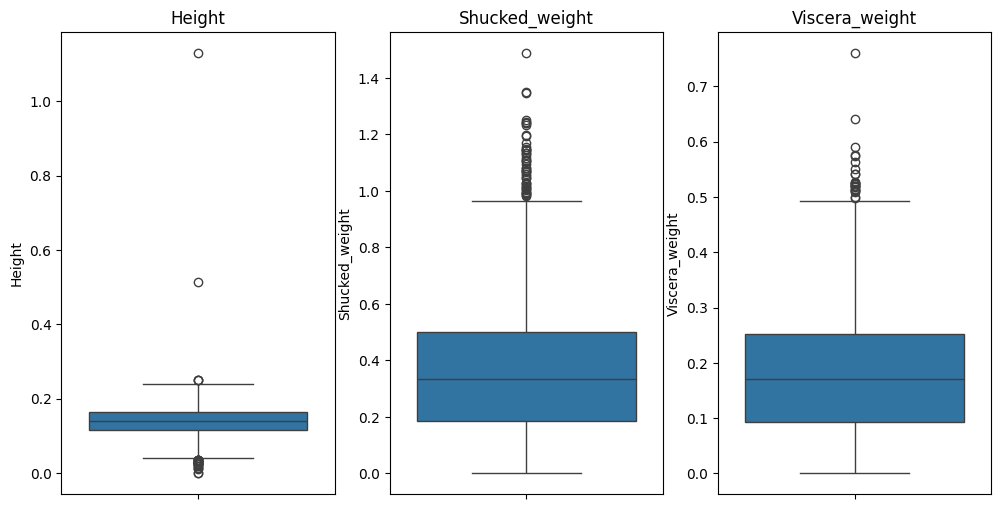

In [6]:
# Plot the columns with null values to understand the distribution
fig, axes = plt.subplots(1,3, figsize=(12,6))

sns.boxplot(y=df["Height"], ax = axes[0])
axes[0].set_title("Height")

sns.boxplot(y=df["Shucked_weight"], ax = axes[1])
axes[1].set_title("Shucked_weight") 

sns.boxplot(y=df["Viscera_weight"], ax = axes[2])
axes[2].set_title("Viscera_weight") 

In [7]:
#I will use Median to replace the null values
df["Height"] = df["Height"].fillna(df["Height"].median())
df["Shucked_weight"] = df["Shucked_weight"].fillna(df["Shucked_weight"].median())
df["Viscera_weight"] = df["Viscera_weight"].fillna(df["Viscera_weight"].median())

In [8]:
# Check if all  the null values were replaced
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

## Check duplicate values

In [9]:
duplicated_values = df[df.duplicated()]

# Before drop
print(f"rows/columns before drop: {df.shape}")

# Drop the duplicated values
df = df.drop(duplicated_values.index, axis=0)

# After drop
print(f"rows/columns after drop: {df.shape}")

rows/columns before drop: (4180, 9)
rows/columns after drop: (4177, 9)


## Encode the Data

In [10]:
# I will use LabelEncoder, because ordinal encoder has an idea of hierarchy, that is not the case and OneHotEncoder will add more 3 columns on data 

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include = [object]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print(le.classes_)                                                  # Display the sequence to identify 0(F),1(I),2(M)

['F' 'I' 'M']


#### This step is important because before training the model, it's important to ensure that all features in the dataset are numeric.

In [11]:
df.head(5)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [12]:
# Now all the columns are numeric, so it is possible to start the preparation to train the data
df.info()

<class 'pandas.DataFrame'>
Index: 4177 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 326.3 KB


## Understanding the features distribution

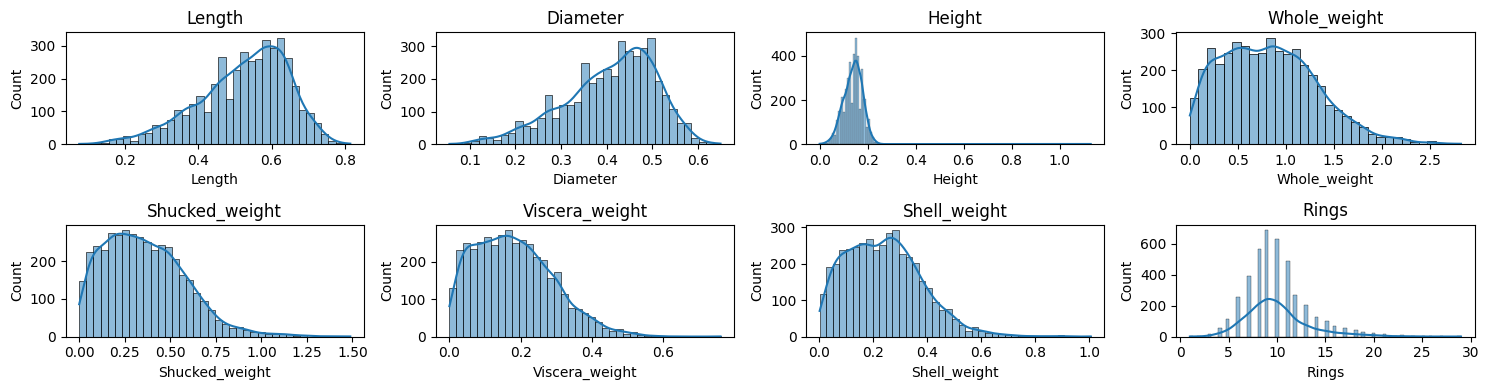

In [13]:
df.columns

# Name of the features
cols = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings']

fig, axes = plt.subplots(2,4, figsize = (15,4))

# Converts a 2D matrix to one-dimensional
axes = axes.flatten()

# Loop to plot each column from the array cols
for i, col in enumerate(cols):
    sns.histplot(df[col], kde =True, ax = axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Features Distribution Analysis

#### Length
Slight right skewness, with most values between **0.5 and 0.7**.

Smaller abalones appear less frequently in the dataset.

#### Diameter
Follows the same pattern as **Length**, with values mainly between **0.35 and 0.5**.

Not surprising length and diameter tend to grow together.

#### Height
Most values are quite low, rarely exceeding **0.2**.

Unlike the other characteristics, height seems to have a natural maximum limit, which makes sense considering the species limitations.

#### Whole Weight
Right skewness with a long tail extending to **2.5**.

Most abalones in the dataset are lighter, meaning there's still a lot of growth ahead for most of them.

#### Shucked Weight
Very similar shape to **Whole Weight**, just with a shorter tail up to **1.5**.

The two clearly measure related things.

#### Viscera Weight
Also with right skewness, but the values remain quite low (mostly between **0 and 0.3**).

The long tail is present, but the numbers themselves don't increase that much.

#### Shell Weight
Looks very similar to **Viscera Weight** and honestly, to most of the other weight columns as well. They all seem to move together.

#### Rings
Stands out from the others. Unlike the other features, the distribution is more discrete, since the values are whole numbers.

Most abalones have between **7 and 15 rings**, with older ones being rare.

----------

### General Observations

- **Height** is clearly the most physically limited characteristic; a flat shell can only reach a maximum height.

- **Weight** characteristics are similar to each other, which we will check in the heatmap.

- Long tails in most characteristics indicate that there are abalones of all sizes, although the smaller ones are the majority.

- Overall, the positive asymmetry in almost all characteristics makes sense for a single species:

- Most individuals cluster around similar sizes, with a smaller group of larger and older individuals that increase in tail size.

## Correlation

Text(0.5, 1.0, 'Correlation between the features')

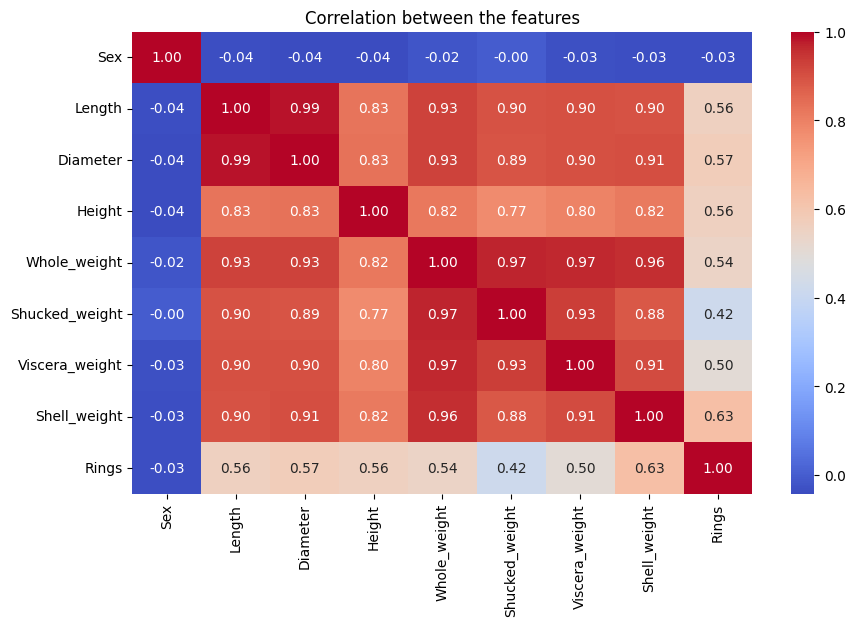

In [14]:
# Plot the correlation between the features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between the features")

### Observations
- Multicollinearity can become a problem for the model's performance.


#### Length and Diameter
Both features show a **very high correlation with each other (0.99)**,
which was expected as seen in the distribution graphs.

---

#### Weight Features
**Whole_weight**, **Shucked_weight**, **Viscera_weight**, and **Shell_weight**
are all **strongly correlated** with each other (ranging from **0.88 to 0.97**).

This confirms the pattern identified in the histogram analysis, where all weight features shared similar shapes and long tails.

---

#### Height
Despite having **less variability** among all features, Height still has a **moderate-high correlation** with the other physical features (**0.77 – 0.83**).

---

#### Rings
The **Rings** feature shows a **moderate correlation** with the physical characteristics (**0.42 – 0.63**),
with the highest correlation with **Shell_weight (0.63)**.

---

#### Sex
The **Sex** feature shows a correlation **close to zero** with all other traits (ranging from **-0.04 to -0.00**), indicating that it has little to no linear relationship with the physical characteristics of abalone.

Since **Rings** is now the target feature, **Sex** becomes one of the predictors. Despite its low correlation with the remaining features, it was retained in the model as it may still help distinguish younger abalones from adults, given that infants tend to present  significantly smaller size and weight measurements.

## Split the data in X(independent) and y(target)

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Sex", axis = 1)                    # Independet variables
y = df["Sex"]                                   # Target variable

## Normalize the data

In [16]:
# Scalling X data, as I explained above
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

print(X_scaled)

        Length  Diameter    Height  Whole_weight  Shucked_weight  \
0    -0.574558 -0.432149 -1.065452     -0.641898       -0.608212   
1    -1.448986 -1.439929 -1.185125     -1.230277       -1.171596   
2     0.050033  0.122130 -0.108069     -0.309469       -0.463985   
3    -0.699476 -0.432149 -0.347415     -0.637819       -0.648775   
4    -1.615544 -1.540707 -1.424470     -1.272086       -1.216666   
...        ...       ...       ...           ...             ...   
4172  0.341509  0.424464  0.609967      0.118813        0.047567   
4173  0.549706  0.323686 -0.108069      0.279929        0.358555   
4174  0.632985  0.676409  1.567350      0.708212        0.748416   
4175  0.841182  0.777187  0.250949      0.541998        0.773205   
4176  1.549052  1.482634  1.328004      2.283681        2.641386   

      Viscera_weight  Shell_weight     Rings  
0          -0.727204     -0.638217  1.571544  
1          -1.206444     -1.212987 -0.910013  
2          -0.357505     -0.207139 -0.2896

In [17]:
# Understand the distribution between the classes (H,M,I)
sex_counts = y.value_counts()

print(sex_counts)

Sex
2    1528
1    1342
0    1307
Name: count, dtype: int64


### It can be noted that there is a moderate balance between the classes: M (1528), F (1342) and I (1307). Despite this balance, there is still a slight difference, which may become a problem when the model predicts sex, as this imbalance can create a bias — a factor that tends to predict the majority class, in this case class M.

## Split the data in training and test

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state = 42)


# Check the train and test sample
X_scaled.shape, y.shape, X_train.shape, X_test.shape

((4177, 8), (4177,), (3759, 8), (418, 8))

## Comparing differents models to find the better choice

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Classifiers = {                      # create the dict
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors = 5),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Logistic Regression": LogisticRegression(solver= 'lbfgs', max_iter = 200, random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators = 100, random_state = 42)
}

In [20]:
# Calculate metrics to understand the models performance

results = []

for name, classifier in Classifiers.items():
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict (X_test)                                    # Predicting the values

    accuracy = accuracy_score(y_test,y_pred)                                # Calculate accuracy of model
    report = classification_report(y_test, y_pred, output_dict = True)      # Create the classification report
    precision = report["weighted avg"]["precision"]                         # select the precision value
    recall = report["weighted avg"]["recall"]                               # select the recall value
    f1_score = report["weighted avg"]["f1-score"]                           # select the f1_score value

            
    results.append([name, accuracy, precision ,recall, f1_score])           # Add the result in the array

In [21]:
# As we can see, the display does not look friendly
results

[['K-Nearest Neighbors',
  0.5311004784688995,
  0.5272334110668322,
  0.5311004784688995,
  0.5259666465017484],
 ['Decision Tree',
  0.49282296650717705,
  0.49001826419744254,
  0.49282296650717705,
  0.49071804233398436],
 ['Logistic Regression',
  0.583732057416268,
  0.5701645525674526,
  0.583732057416268,
  0.5721492307351359],
 ['Random Forest',
  0.5669856459330144,
  0.5577266849118158,
  0.5669856459330144,
  0.5613794706271424]]

In [22]:
results_df = pd.DataFrame(results, columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score"])      # Create the DataFrame with the values
print("              ----- Model performance on test sample -----")
print(results_df)                                                                                           # Display the DataFrame

              ----- Model performance on test sample -----
                 Model  Accuracy  Precision    Recall  F1-Score
0  K-Nearest Neighbors  0.531100   0.527233  0.531100  0.525967
1        Decision Tree  0.492823   0.490018  0.492823  0.490718
2  Logistic Regression  0.583732   0.570165  0.583732  0.572149
3        Random Forest  0.566986   0.557727  0.566986  0.561379


###### This report means:

- **Accuracy** – The total percentage of correct predictions across the entire dataset.
- **Precision** – The percentage of correct predictions for the positive class (in this case, class H).
- **Recall** – The percentage of true positives that were correctly identified by the model.
- **F1-score** – This is the balance between recall and precision. A low value indicates an issue, even if precision or recall is high value

In [23]:
# Apply k fold cross validation to asess model robustness

cv_results = []                                                                                      # Create array to save the values
for name, classifier in Classifiers.items():
    cv_scores = cross_val_score(classifier, X, y, cv = 5, scoring = "accuracy")
    cv_results.append([name, cv_scores.mean()])                                                      # Add the values in the array

In [24]:
cv_results_df = pd.DataFrame(cv_results, columns = ["Model", "Mean CV Accuracy"])                    # Create the DataFrame

print("Model Performance using cross validation")

print(cv_results_df)

Model Performance using cross validation
                 Model  Mean CV Accuracy
0  K-Nearest Neighbors          0.523817
1        Decision Tree          0.496048
2  Logistic Regression          0.552075
3        Random Forest          0.540100


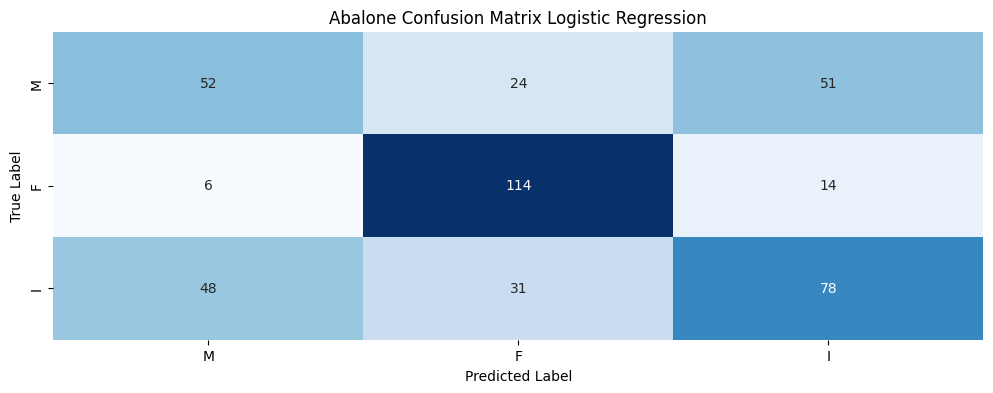

In [25]:
# Now I know the best model, and these values were inputed in Classifiers[]

y_pred_logistic = Classifiers["Logistic Regression"].predict(X_test)    # Predict again using the best model

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic) 
plt.figure(figsize = (12, 4))                                            # Set figure size
sns.heatmap(
    cm,                                                                 # Confusion matrix values
    annot=True,                                                         # Show numbers in each cell
    fmt="d",                                                            # Integer format
    cmap="Blues",                                                       # Colour theme
    cbar=False,                                                         # remove scale bar
    xticklabels=["M", "F","I"],                                         # Predicted labels
    yticklabels=["M", "F","I"]                                          # True labels
)

plt.xlabel("Predicted Label")                                           # X-axis label
plt.ylabel("True Label")                                                # Y-axis label
plt.title("Abalone Confusion Matrix Logistic Regression")               # Plot title
plt.show()

##### Considering class M as the true class, and the others as false, the matrix confirms a high error rate. For example, if abalones are sex = M, the sum of errors is greater than the sum of correct answers. Considering the classes considered negative, they had a higher success rate, even though one of the classes also had more errors than correct answers. In this dataset these errors are not so serious if we compare them to something related to finance, health, etc. However, it becomes more obvious that the model is not functioning correctly.

## Try differents target features

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 4177 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 326.3 KB


Text(0.5, 1.0, 'Correlation between the features')

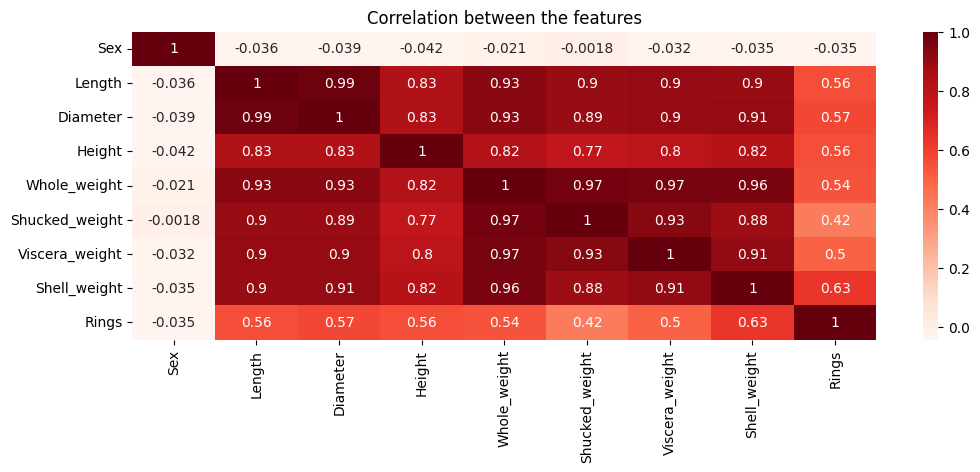

In [27]:
# Get the correlation between the columns
correlation_df = df.corr()                                              # Variable to store the correlation


# Create the heatmap with the correlation
plt.figure(figsize = (12, 4))                                           # Set figure size
sns.heatmap(
    correlation_df,                                                     # Confusion matrix values
    annot=True,                                                         # Show numbers in each cell
    cmap="Reds",                                                        # Colour theme
)
plt.title("Correlation between the features")                           # Plot title

## Since using the "Sex" feature as a target did not yield a good model, I will now use different models and parameters to predict continuous columns.

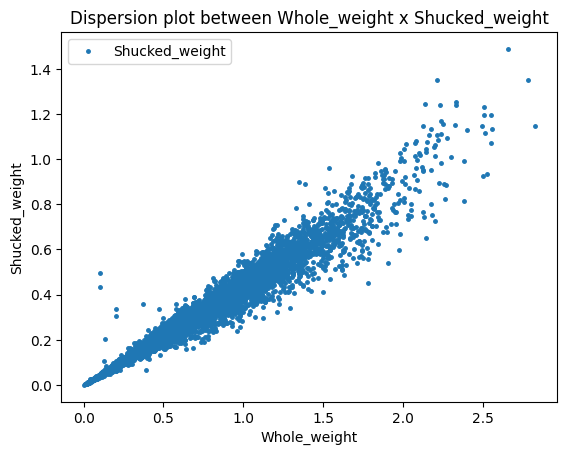

In [28]:
# Plot a scatter plot of few features from the dataset 
df.plot(x = "Whole_weight", y = "Shucked_weight", style=".", markersize = 5)

# Add a title to the plot
plt.title('Dispersion plot between Whole_weight x Shucked_weight')  

# Label the x-axis
plt.xlabel('Whole_weight')  

# Label the y-axis
plt.ylabel('Shucked_weight')  

# Display the plot
plt.show() 

##### In this plot, we see the relationship between the "Shucked Weight" and "Whole_weight" columns. There is a strong correlation between them. The graph is linear, indicating that the higher the total weight, the greater the weight when considering only the meat. There is no visible outliers.

## Split the data in X and y

In [29]:
# Split into X and y
X = df.drop(columns = ["Shucked_weight"])         # Independent variable

y_sw = df["Shucked_weight"]                       # Target variable

## Split the data in training and test

In [30]:
# As I did before, I need to split in training and testand normalize
X_train, X_test, y_train, y_test = train_test_split(X, y_sw, test_size=0.1, random_state=42)

## Regularize the data to improve the performance

## Alphas Values:

> The Ridge alpha (10.0) was set high in order to aggressively reduce the feature coefficients, penalising the model's complexity. The Lasso alpha (0.0001) was kept low to maintain a good performance balance, without zeroing too many coefficients.

In [31]:
from sklearn.pipeline import Pipeline                  # Combine preprocessing and models
from sklearn.linear_model import LinearRegression      # Ordinary Least Squares regression

from sklearn.linear_model import Lasso                 # Lasso regression (L1 regularisation)
from sklearn.linear_model import Ridge                 # Ridge regression (L2 regularisation)



# Regularisation strengths (hyperparameters)
alpha_ridge = 10.0                                     # Larger value -> stronger L2 penalty -> more coefficient shrinkage
alpha_lasso = 0.0001                                   # Larger value -> stronger L1 penalty -> more coefficients set to zero


# Define models using pipelines (scaling + regression)
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),                  # Standardise features (mean=0, std=1)
        ("model", LinearRegression())                  # Ordinary Least Squares regression
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),                  # Scaling required for L2 regularisation
        ("model", Ridge(alpha = alpha_ridge))          # Ridge regression (L2 penalty)
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),                  # Scaling required for L1 regularisation
        ("model", Lasso(
            alpha=alpha_lasso,                         # L1 regularisation strength
            max_iter = 20000                          # Increase iterations to ensure convergence
        ))
    ]),
}

## Check and interpret the results.

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error ,r2_score as r2   # Evaluation metrics

results = {}   # Dictionary to store model results

print("\n Test Performance (MSE, R²) ")   # Header for output

# Loop through each model (Linear, Ridge, Lasso)
for name, pipe in models.items():
    pipe.fit(X_train, y_train)          # Train model on training data
    preds = pipe.predict(X_test)        # Predict target values for test data

# Store evaluation metrics and model parameters
    results[name] = {
        "mse": mean_squared_error(y_test, preds),            # Mean Squared Error
        "r2": r2(y_test, preds),                             # R-squared score
        "mae": mean_absolute_error(y_test, preds),           # Mean Absolute Error
        "coefficients": pipe.named_steps["model"].coef_,     # Model coefficients
        "intercept": pipe.named_steps["model"].intercept_    # Model intercept
        }
    
# Print performance results for each model
    print(
        f"{name:6s} | "
        f"MSE = {results[name]['mse']:.4f} | "
        f"MAE = {results[name]['mae']:.4f} |"
        f"R² = {results[name]['r2']:.4f} "
        )


 Test Performance (MSE, R²) 
Linear | MSE = 0.0019 | MAE = 0.0236 |R² = 0.9555 
Ridge  | MSE = 0.0017 | MAE = 0.0243 |R² = 0.9583 
Lasso  | MSE = 0.0018 | MAE = 0.0236 |R² = 0.9561 


#### MSE (Mean Squared Error) and MAE (Mean Absolute Error)

In general, they differ in how they penalize errors:

- **MSE** is quadratic, errors are penalized more heavily; however, this makes it more sensitive to outliers.
- **MAE** is more robust and penalizes errors in the same way, making this metric simpler to interpret. In the case of the model in question, both values are low.
- **R²** evaluates the coefficient of variation — the percentage that the model can predict/explain — indicating good model performance.

---

Ridge achieved the best MSE (0.0018), slightly below Linear (0.0019). This can be explained by the high multicollinearity present in the dataset — Length and Diameter have a correlation of 0.99, and the weight-related features are also strongly correlated with each other, making generalisation harder for unregularised models. Ridge handles this by shrinking coefficients, distributing the weight more evenly across correlated features. Lasso, on the other hand, was configured with a very low alpha, causing it to behave very similarly to Linear regression, which explains the near-identical results between both models.

In [33]:
# Ensure feature names correspond exactly to the columns used in training
feature_names = list(X.columns)

# Create a table of coefficients for each model
coef_table = pd.DataFrame({
    "feature": feature_names,                                     # Feature names
    "Linear": np.ravel(results["Linear"]["coefficients"]),        # Linear regression coefficients
    "Ridge":  np.ravel(results["Ridge"]["coefficients"]),         # Ridge regression coefficients (L2)
    "Lasso":  np.ravel(results["Lasso"]["coefficients"]),         # Lasso regression coefficients (L1)
})

# Sort features by absolute Linear coefficient (importance ranking)
coef_table["abs_linear"] = coef_table["Linear"].abs()
coef_table = (
    coef_table
    .sort_values("abs_linear", ascending=False)
    .drop(columns=["abs_linear"])
)

# Display coefficient table
print("\n Coefficients (sorted by |Linear|) ")
print(coef_table.to_string(index=False))

# Count how many coefficients Lasso shrinks to (near) zero
lasso_zeros = np.sum(np.isclose(coef_table["Lasso"].values, 0.0))
print(f"\nLasso set {lasso_zeros} out of {len(feature_names)} coefficients to (near) zero.")


 Coefficients (sorted by |Linear|) 
       feature    Linear     Ridge     Lasso
  Whole_weight  0.351476  0.315859  0.345176
  Shell_weight -0.101948 -0.084961 -0.098551
Viscera_weight -0.048548 -0.031656 -0.044700
         Rings -0.019307 -0.021126 -0.019428
        Length  0.019124  0.020471  0.018963
           Sex  0.002302  0.002759  0.002276
      Diameter  0.001832  0.004053  0.001530
        Height  0.000786  0.000662  0.000452

Lasso set 0 out of 8 coefficients to (near) zero.


#### With the information above, it is possible to understand the importance of each variable in the model. In this case, the closer to 0, the less important that feature is for the model. Since 0 represents a feature that adds nothing, however, if it is negative, despite being less than 0, it has representativeness, but it reduces the target feature.

<Figure size 640x480 with 0 Axes>

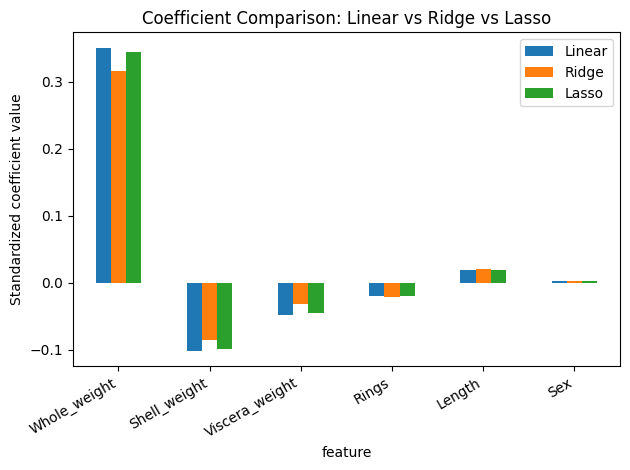

In [34]:
# Select top features for visualisation (limit to 6 for readability)
top_k = min(6, len(feature_names))     # Ensure we do not exceed available features

# Prepare data for plotting (use most important features)
plot_df = coef_table.head(top_k).set_index("feature")

# Create bar plot to compare coefficients across models
plt.figure()                                                         # Create a new figure
plot_df.plot(kind="bar")                                             # Bar chart of coefficients
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")        # Plot title
plt.ylabel("Standardized coefficient value")                         # Y-axis label
plt.xticks(rotation=30, ha="right")                                  # Rotate feature labels for readability
plt.tight_layout()                                                   # Adjust layout to prevent overlap
plt.show()                                                           # Display the plot

#### This graph visually illustrates the importance of each variable within the three models on which the data was trained. 

#### As seen above, "Whole_weight" has a strong correlation with the target variable. 

#### We also see the difference in performance when comparing the two regularized models with linear regression.

## K-Fold Cross validation

In [35]:
# Apply K-fold-cross validation on the chosen model
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

k = 10                                          
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Initializate the Ridge regression model
model = Ridge()

X = df.drop('Shucked_weight', axis = 1)
y = df.iloc[:, 5]

#Perform Cross Validation
scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print(f"Accuracy for each fold: {scores}")


average_accuracy = np.mean(scores)
print(f"Std between folds: {scores.std():.4f}")                                 # Std between folds
print(f"Average Ridge regression Accuracy: {average_accuracy:.3f}")             # Average Accuracy

Accuracy for each fold: [0.95850018 0.94932206 0.96593833 0.97676249 0.96832571 0.96881906
 0.96489692 0.97398487 0.97304924 0.97285994]
Std between folds: 0.0078
Average Ridge regression Accuracy: 0.967


### Result


> The average R² of 0.967, combined with a low standard deviation across folds, confirms that despite different data splits, the model is consistent and did not suffer from overfitting. By analysing the mean R² across 10 folds, the element of "luck" at the moment of the split is eliminated, further confirming the model's stability and generalisation ability.